<a href="https://colab.research.google.com/github/hassan1303/Vegetable_Image_Classification/blob/main/Vegetable_Image_Classification_Alexnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ArewaDS Deep Learning Cohort 2.0 – Capstone Project  
### Project Title: Deep Learning-Based Vegetable Image Classification


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
!pip install -q wandb
import wandb
wandb.login()
wandb.init(project="vegetable-classification", name="AlexNet", reinit=True)





wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [3]:
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
import random
from PIL import Image

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
data_dir = "/content/drive/MyDrive/Vegetables_Classification_Project/Vegetable_Images"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "validation")
test_dir = os.path.join(data_dir, "test")

batch_size = 8

data_transforms = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ]),
    "validation": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ]),
    "test": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ]),
}

image_datasets = {
    "train": datasets.ImageFolder(train_dir, transform=data_transforms["train"]),
    "validation": datasets.ImageFolder(val_dir, transform=data_transforms["validation"]),
    "test": datasets.ImageFolder(test_dir, transform=data_transforms["test"])
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True, num_workers=2)
    for x in ["train", "validation", "test"]
}

class_names = image_datasets["train"].classes
print(class_names)

['Cabbage', 'Carrot', 'Cucumber', 'Tomato']


In [6]:
for inputs, labels in dataloaders["train"]:
    print("Loaded batch shape:", inputs.shape)
    break

Loaded batch shape: torch.Size([8, 3, 224, 224])


In [8]:
def visualize_imgs_from_dataset(image_folder_dataset, class_names, pts_per_class=3, color_scale=None):
    """
    Visualize sample images from an ImageFolder dataset.

    Parameters:
    - image_folder_dataset: dataset returned by torchvision.datasets.ImageFolder
    - class_names: list of class names
    - pts_per_class: number of images to show per class
    - color_scale: 'gray' or None (RGB)
    """
    # Create a dictionary to hold image paths per class
    class_to_images = {class_name: [] for class_name in class_names}

    for path, label in image_folder_dataset.samples:
        class_name = class_names[label]
        class_to_images[class_name].append(path)

    plt.rcParams["axes.grid"] = False

    for pt in range(pts_per_class):
        fig, axarr = plt.subplots(1, len(class_names), figsize=(15, 3))
        if len(class_names) == 1:
            axarr = [axarr]
        axarr[0].set_ylabel("Sample {}".format(pt + 1))

        for i, class_name in enumerate(class_names):
            img_path = random.choice(class_to_images[class_name])
            img = Image.open(img_path).resize((224, 224))

            if color_scale == 'gray':
                img = img.convert('L')
                axarr[i].imshow(img, cmap='gray')
            else:
                axarr[i].imshow(img)

            axarr[i].set_title(class_name)
            axarr[i].axis('off')

        plt.tight_layout()
        plt.show()


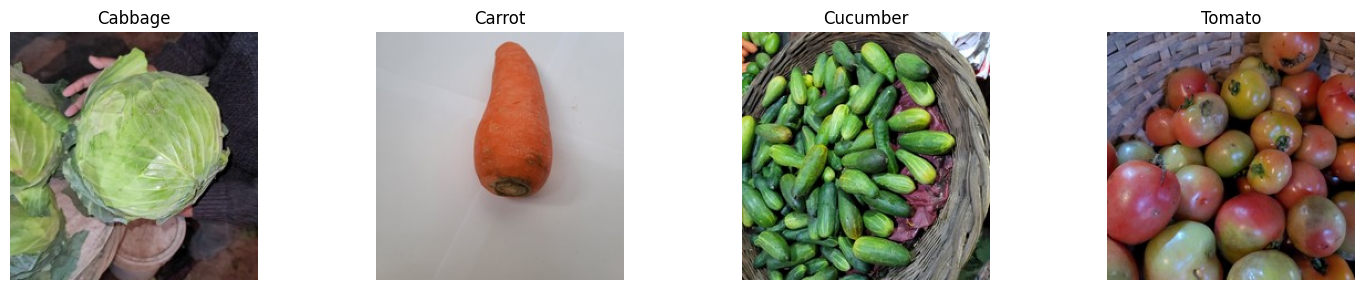

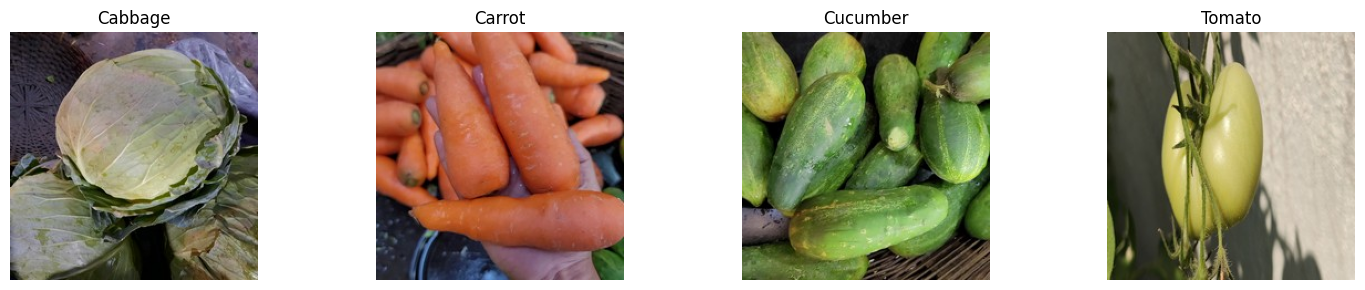

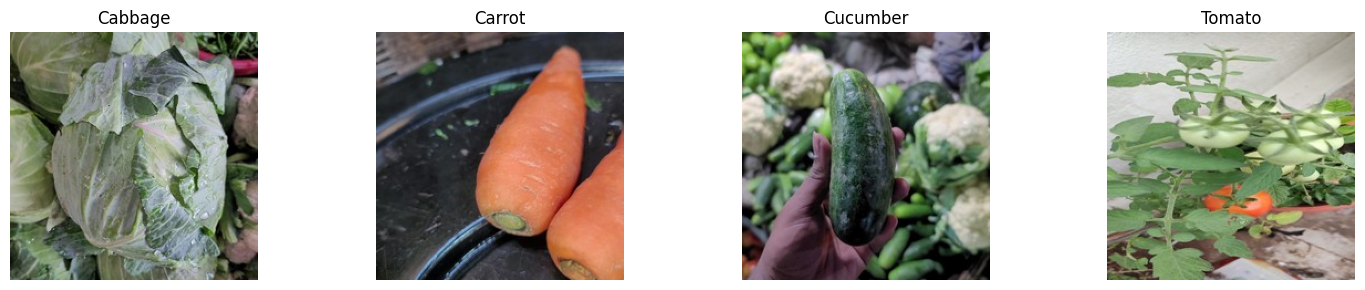

In [9]:
visualize_imgs_from_dataset(image_datasets["train"], class_names, pts_per_class=3, color_scale=None)

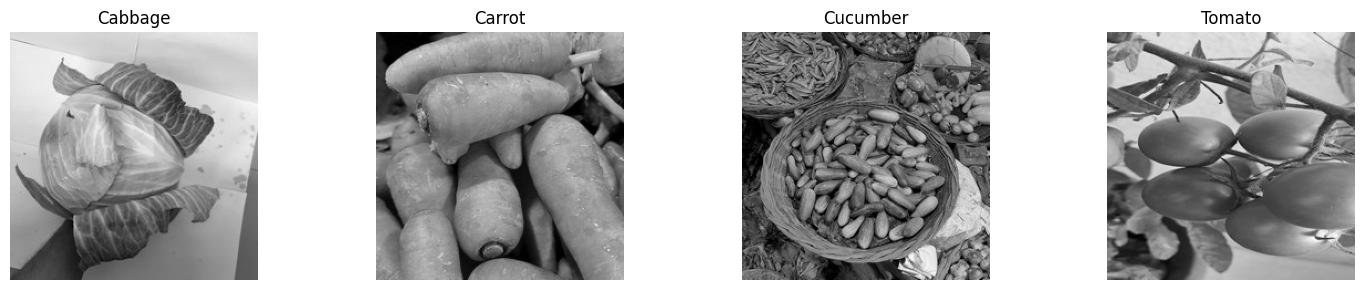

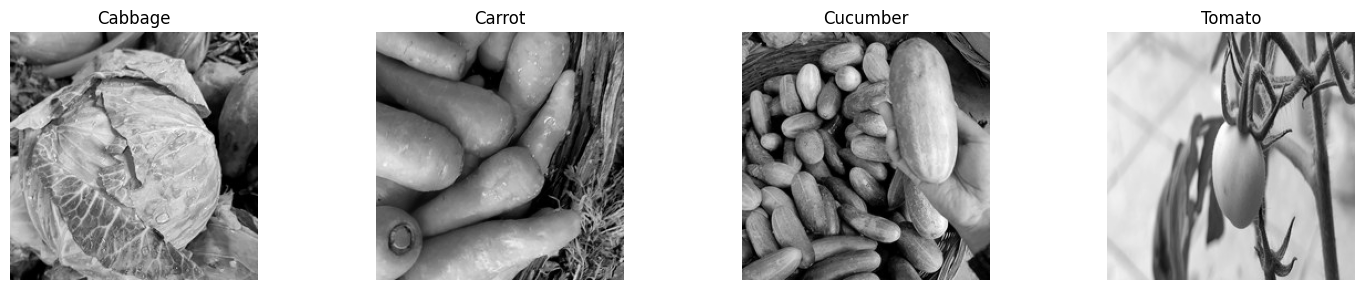

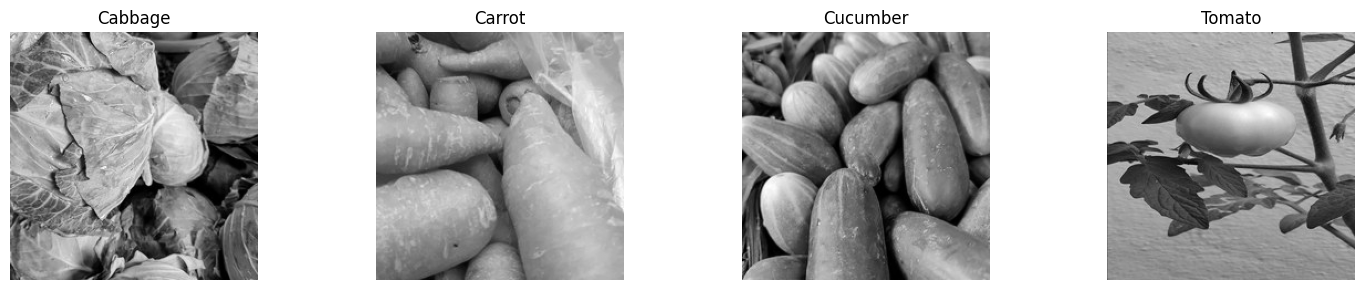

In [10]:
visualize_imgs_from_dataset(image_datasets["train"], class_names, pts_per_class=3, color_scale='gray')

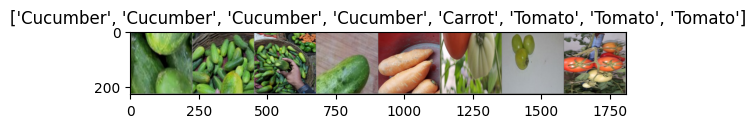

In [11]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    inp = inp * 0.5 + 0.5
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.pause(0.001)

inputs, classes = next(iter(dataloaders["train"]))
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[c] for c in classes])


In [12]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_alexnet():
    model = models.alexnet(pretrained=True)
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_ftrs, len(class_names))
    return model.to(device)
model = get_alexnet()

# Print device and model
print(f"Using device: {device}")
print(model)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:01<00:00, 135MB/s]


Using device: cpu
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=

In [13]:
def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=10):
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        for phase in ['train', 'validation']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])
            epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
            epoch_precision = precision_score(all_labels, all_preds, average='weighted')
            epoch_recall = recall_score(all_labels, all_preds, average='weighted')

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} "
                  f"Precision: {epoch_precision:.4f} Recall: {epoch_recall:.4f} F1: {epoch_f1:.4f}")

            # Log metrics to wandb
            wandb.log({
                f"{phase}_loss": epoch_loss,
                f"{phase}_accuracy": epoch_acc.item(),
                f"{phase}_precision": epoch_precision,
                f"{phase}_recall": epoch_recall,
                f"{phase}_f1": epoch_f1,
                "epoch": epoch + 1,
                **({ "learning_rate": scheduler.get_last_lr()[0] } if phase == 'train' else {})
            })

    return model


In [14]:
def evaluate_model(model, dataloader, class_names, device):
    import wandb
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="YlGnBu")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    plt.show()

    # Metrics
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Log to WandB
    wandb.log({
        "eval_accuracy": acc,
        "eval_precision": precision,
        "eval_recall": recall,
        "eval_f1": f1,
        "eval_confusion_matrix": wandb.Image("confusion_matrix.png")
    })


In [15]:

# Load models
alexnet_model = get_alexnet()

# Define loss function
criterion = nn.CrossEntropyLoss()

# AlexNet setup
optimizer_alexnet = optim.SGD(alexnet_model.parameters(), lr=0.001, momentum=0.9)
scheduler_alexnet = optim.lr_scheduler.StepLR(optimizer_alexnet, step_size=7, gamma=0.1)



In [18]:
# Train model alexnet
trained_alexnet = train_model(alexnet_model, dataloaders, criterion, optimizer_alexnet, scheduler_alexnet, num_epochs=10)


Epoch 1/10
Train Loss: 0.0775 Acc: 0.9716 Precision: 0.9715 Recall: 0.9716 F1: 0.9715
Validation Loss: 0.0124 Acc: 0.9962 Precision: 0.9963 Recall: 0.9962 F1: 0.9963
Epoch 2/10
Train Loss: 0.0522 Acc: 0.9803 Precision: 0.9803 Recall: 0.9803 F1: 0.9803
Validation Loss: 0.0021 Acc: 0.9988 Precision: 0.9988 Recall: 0.9988 F1: 0.9987
Epoch 3/10
Train Loss: 0.0416 Acc: 0.9843 Precision: 0.9843 Recall: 0.9843 F1: 0.9843
Validation Loss: 0.0018 Acc: 0.9988 Precision: 0.9988 Recall: 0.9988 F1: 0.9987
Epoch 4/10
Train Loss: 0.0288 Acc: 0.9903 Precision: 0.9903 Recall: 0.9903 F1: 0.9903
Validation Loss: 0.0008 Acc: 1.0000 Precision: 1.0000 Recall: 1.0000 F1: 1.0000
Epoch 5/10
Train Loss: 0.0241 Acc: 0.9908 Precision: 0.9908 Recall: 0.9908 F1: 0.9908
Validation Loss: 0.0001 Acc: 1.0000 Precision: 1.0000 Recall: 1.0000 F1: 1.0000
Epoch 6/10
Train Loss: 0.0287 Acc: 0.9898 Precision: 0.9898 Recall: 0.9898 F1: 0.9898
Validation Loss: 0.0019 Acc: 1.0000 Precision: 1.0000 Recall: 1.0000 F1: 1.0000
Epoc


Classification Report:

              precision    recall  f1-score   support

     Cabbage       0.05      0.04      0.04       200
      Carrot       0.06      0.05      0.05       200
    Cucumber       0.24      0.32      0.27       200
      Tomato       0.13      0.13      0.13       200

    accuracy                           0.13       800
   macro avg       0.12      0.13      0.12       800
weighted avg       0.12      0.13      0.12       800



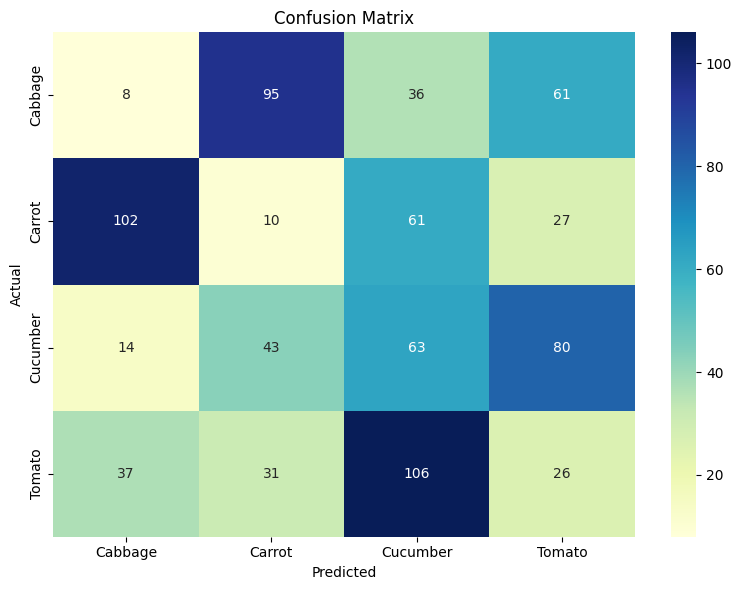

Accuracy: 0.1338
Precision: 0.1191
Recall: 0.1338
F1 Score: 0.1249


epoch,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇██
eval_accuracy,▁
eval_f1,▁
eval_precision,▁
eval_recall,▁
learning_rate,██████▁▁▁▁
train_accuracy,▁▄▅▆▇▆▆███
train_f1,▁▄▅▆▇▆▆███
train_loss,█▅▄▃▂▃▃▂▁▁
train_precision,▁▄▅▆▇▆▆███
train_recall,▁▄▅▆▇▆▆███


In [20]:
evaluate_model(model, dataloaders["test"], class_names, device)
wandb.finish()


In [19]:
torch.save(model, "/content/drive/MyDrive/Vegetables_Classification_Project/Vegetable_Images/alexnet_model.pth")
